Install CAFA EVAL Package

In [ ]:
!pip install pronto


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd

**Reading all Ground Truth Files**

In [ ]:
pip install cafaeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 2.9 MB/s eta 0:00:00


#Predictions using CAFA EVAL

In [8]:
import cafaeval
from cafaeval.evaluation import cafa_eval, write_results

In [ ]:
# Load each TSV file into a DataFrame
df_bpo = pd.read_csv('Ground_Truth_Struct_Protgoat_BPO.tsv',sep='\t')
df_cco = pd.read_csv('Ground_Truth_Struct_Protgoat_CCO.tsv',sep='\t')
df_mfo = pd.read_csv('Ground_Truth_Struct_Protgoat_MFO.tsv',sep='\t')

# Concatenate the DataFrames vertically
df_combined = pd.concat([df_bpo, df_cco, df_mfo])
df_combined=df_combined[['Protein_ID','GO_Term']]


# Optionally, save the combined DataFrame to a new TSV file
df_combined.to_csv('Combined_Ground_Truth.tsv',sep='\t',index=False,header=False)

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
all_data = '/content/drive/Shared drives/CAFA-5: ECEN766 Final Project/'
import os
all_data=os.listdir(all_data)

all_data


['Documents',
 'CAFA-5_starting_point.ipynb',
 'data',
 'cafa-5-protein-function-prediction.zip',
 'code_explanation.mp4',
 'code_from_chris.zip',
 'Train_Structural_Embeddings_All.csv',
 'PROTGOAT_embeddings',
 '0503_meeting.mp4',
 'struct_embeddings.npy',
 '.ipynb_checkpoints',
 '__pycache__',
 'Train',
 'IA.txt',
 'Test (Targets)',
 'Annotated_dates_list.csv',
 'embedding-protein-struct.ipynb',
 'models',
 'model_logs',
 'final_submissions',
 'preprocess.py',
 'reordered_struct_embed.npy',
 'GROUND_TRUTH_STRUCT_PROTGOAT',
 'main.ipynb',
 'parameters.py',
 '0505_meeting.mp4',
 'Predictions_Total',
 'predictions',
 'IDPO_disorder_function.obo',
 'ground_truth.tsv']

In [6]:
cd "drive/Shareddrives/CAFA-5: ECEN766 Final Project"

/content/drive/Shareddrives/CAFA-5: ECEN766 Final Project


In [ ]:
!pwd

/content/drive/Shareddrives/CAFA-5: ECEN766 Final Project


In [9]:
res=cafa_eval("IDPO_disorder_function.obo", "predictions", "ground_truth.tsv")
write_results(*res)

In [10]:
write_results

<function cafaeval.evaluation.write_results(df, dfs_best, out_dir='results', th_step=0.01)>

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.set_loglevel("info")

In [59]:
# Input files
df_file = "results_cafa_eval_struct/evaluation_all.tsv"
out_folder = "results_viz_prot_struct"

# Set to None if you don't want to use it. Results will not be grouped/filtered by team
names_file = None

# Cumulate the last column of the cols variable, e.g. "pr" --> precision, so that the curves are monotonic as in CAFA
cumulate = True

# Add extreme points to the precision-recall curves (0, 1) and (1, 0)
add_extreme_points = True

# Methods with coverage below this threshold will not be plotted
coverage_threshold = 0.1

# Select a metric
# metric, cols = ('f', ['rc', 'pr'])
#metric, cols =  ('f_w', ['rc_w', 'pr_w'])
metric, cols =  ('f_micro', ['rc_micro', 'pr_micro'])
# metric, cols =  ('f_micro_w', ['rc_micro_w', 'pr_micro_w'])
# metric, cols = ('s_w', ['ru_w', 'mi_w'])

In [60]:
# Map column names to full names (for axis labels)
axis_title_dict = {'pr': 'Precision', 'rc': 'Recall', 'f': 'F-score', 'pr_w': 'Weighted Precision', 'rc_w': 'Weighted Recall', 'f_w': 'Weighted F-score', 'mi': 'Misinformation (Unweighted)', 'ru': 'Remaining Uncertainty (Unweighted)', 'mi_w': 'Misinformation', 'ru_w': 'Remaining Uncertainty', 's': 'S-score', 'pr_micro': 'Precision (Micro)', 'rc_micro': 'Recall (Micro)', 'f_micro': 'F-score (Micro)', 'pr_micro_w': 'Weighted Precision (Micro)', 'rc_micro_w': 'Weighted Recall (Micro)', 'f_micro_w': 'Weighted F-score (Micro)'}

# Map ontology namespaces to full names (for plot titles)
ontology_dict = {'biological_process': 'BPO', 'molecular_function': 'MFO', 'cellular_component': 'CCO'}

In [61]:
df = pd.read_csv(df_file, sep="\t")
df

,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro
0,BPO_struct_protgoat_tss.tsv,biological_process,0.01,1882.0,2.573,93.615,29.762,0.082,0.112,0.177,93.615,29.762,0.095,98.232,0.027,0.080,0.040
1,BPO_struct_protgoat_tss.tsv,biological_process,0.02,1882.0,2.573,93.615,29.762,0.082,0.112,0.177,93.615,29.762,0.095,98.232,0.027,0.080,0.040
2,BPO_struct_protgoat_tss.tsv,biological_process,0.03,1882.0,2.573,93.615,29.762,0.082,0.112,0.177,93.615,29.762,0.095,98.232,0.027,0.080,0.040
3,BPO_struct_protgoat_tss.tsv,biological_process,0.04,1882.0,2.573,93.615,29.762,0.082,0.112,0.177,93.615,29.762,0.095,98.232,0.027,0.080,0.040
4,BPO_struct_protgoat_tss.tsv,biological_process,0.05,1882.0,2.573,93.615,29.762,0.082,0.112,0.177,93.615,29.762,0.095,98.232,0.027,0.080,0.040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,CCO_struct_protgoat_tss.tsv,cellular_component,0.95,10892.0,9.855,101.522,2.352,0.090,0.840,0.998,101.522,2.352,0.163,101.550,0.088,0.807,0.159
293,CCO_struct_protgoat_tss.tsv,cellular_component,0.96,10892.0,9.855,101.522,2.352,0.090,0.840,0.998,101.522,2.352,0.163,101.550,0.088,0.807,0.159
294,CCO_struct_protgoat_tss.tsv,cellular_component,0.97,10890.0,9.845,101.317,2.362,0.090,0.839,0.998,101.317,2.362,0.163,101.345,0.089,0.807,0.160
295,CCO_struct_protgoat_tss.tsv,cellular_component,0.98,10863.0,9.823,100.839,2.384,0.090,0.837,0.996,100.839,2.384,0.163,100.867,0.089,0.805,0.160


In [62]:
# Set method information (optional)
if names_file is None:
    df['group'] = df['filename']
    df['label'] = df['filename']
    df['is_baseline'] = False
else:
    methods = pd.read_csv(names_file, delim_whitespace=True, header=0)
    df = pd.merge(df, methods, on='filename', how='left')
    df['group'].fillna(df['filename'], inplace=True)
    df['label'].fillna(df['filename'], inplace=True)
    if 'is_baseline' not in df:
        df['is_baseline'] = False
    else:
        df['is_baseline'].fillna(False, inplace=True)
    # print(methods)
df = df.drop(columns='filename').set_index(['group', 'label', 'ns', 'tau'])
df

n  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   1882.0   
                                                                           0.02   1882.0   
                                                                           0.03   1882.0   
                                                                           0.04   1882.0   
                                                                           0.05   1882.0   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  10892.0   
                                                                           0.96  10892.0   
                                                                           0.97  10890.0   
                                                                           0.98  10863.0   
                                                                           0.99  10862.0   

                                                                                    tp  \
group                       label                       ns                 tau           
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  2.573   
                                                                           0.02  2.573   
                                                                           0.03  2.573   
                                                                           0.04  2.573   
                                                                           0.05  2.573   
...                                                                                ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  9.855   
                                                                           0.96  9.855   
                                                                           0.97  9.845   
                                                                           0.98  9.823   
                                                                           0.99  9.781   

                                                                                      fp  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   93.615   
                                                                           0.02   93.615   
                                                                           0.03   93.615   
                                                                           0.04   93.615   
                                                                           0.05   93.615   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  101.522   
                                                                           0.96  101.522   
                                                                           0.97  101.317   
                                                                           0.98  100.839   
                                                                           0.99   98.815   

                                                                                     fn  \
group                       label                       ns                 tau            
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  29.762   
                                                                           0.02  29.762   
                                                                           0.03  29.762   
                                                                   

In [63]:
# Filter by coverage
df = df[df['cov'] >= coverage_threshold]
df

n  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   1882.0   
                                                                           0.02   1882.0   
                                                                           0.03   1882.0   
                                                                           0.04   1882.0   
                                                                           0.05   1882.0   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  10892.0   
                                                                           0.96  10892.0   
                                                                           0.97  10890.0   
                                                                           0.98  10863.0   
                                                                           0.99  10862.0   

                                                                                    tp  \
group                       label                       ns                 tau           
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  2.573   
                                                                           0.02  2.573   
                                                                           0.03  2.573   
                                                                           0.04  2.573   
                                                                           0.05  2.573   
...                                                                                ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  9.855   
                                                                           0.96  9.855   
                                                                           0.97  9.845   
                                                                           0.98  9.823   
                                                                           0.99  9.781   

                                                                                      fp  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   93.615   
                                                                           0.02   93.615   
                                                                           0.03   93.615   
                                                                           0.04   93.615   
                                                                           0.05   93.615   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  101.522   
                                                                           0.96  101.522   
                                                                           0.97  101.317   
                                                                           0.98  100.839   
                                                                           0.99   98.815   

                                                                                     fn  \
group                       label                       ns                 tau            
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  29.762   
                                                                           0.02  29.762   
                                                                           0.03  29.762   
                                                                   

In [64]:
# Assign colors based on group
cmap = plt.get_cmap('tab20')
df['colors'] = df.index.get_level_values('group')
df['colors'] = pd.factorize(df['colors'])[0]
df['colors'] = df['colors'].apply(lambda x: cmap.colors[x % len(cmap.colors)])
df

n  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   1882.0   
                                                                           0.02   1882.0   
                                                                           0.03   1882.0   
                                                                           0.04   1882.0   
                                                                           0.05   1882.0   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  10892.0   
                                                                           0.96  10892.0   
                                                                           0.97  10890.0   
                                                                           0.98  10863.0   
                                                                           0.99  10862.0   

                                                                                    tp  \
group                       label                       ns                 tau           
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  2.573   
                                                                           0.02  2.573   
                                                                           0.03  2.573   
                                                                           0.04  2.573   
                                                                           0.05  2.573   
...                                                                                ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  9.855   
                                                                           0.96  9.855   
                                                                           0.97  9.845   
                                                                           0.98  9.823   
                                                                           0.99  9.781   

                                                                                      fp  \
group                       label                       ns                 tau             
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01   93.615   
                                                                           0.02   93.615   
                                                                           0.03   93.615   
                                                                           0.04   93.615   
                                                                           0.05   93.615   
...                                                                                  ...   
CCO_struct_protgoat_tss.tsv CCO_struct_protgoat_tss.tsv cellular_component 0.95  101.522   
                                                                           0.96  101.522   
                                                                           0.97  101.317   
                                                                           0.98  100.839   
                                                                           0.99   98.815   

                                                                                     fn  \
group                       label                       ns                 tau            
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process 0.01  29.762   
                                                                           0.02  29.762   
                                                                           0.03  29.762   
                                                                   

In [65]:
# Identify the best methods and thresholds
index_best = df.groupby(level=['group', 'ns'])[metric].idxmax() if metric in ['f','f_micro', 'f_w','f_micro_w'] else df.groupby(['group', 'ns'])[metric].idxmin()
index_best

group                        ns                
BPO_struct_protgoat_tss.tsv  biological_process    (BPO_struct_protgoat_tss.tsv, BPO_struct_protg...
CCO_struct_protgoat_tss.tsv  cellular_component    (CCO_struct_protgoat_tss.tsv, CCO_struct_protg...
MFO_struct_protgoat_tss.tsv  molecular_function    (MFO_struct_protgoat_tss.tsv, MFO_struct_protg...
Name: f_micro, dtype: object

In [66]:
# Filter the dataframe for the best methods
df_methods = df.reset_index('tau').loc[[ele[:-1] for ele in index_best], ['tau', 'cov', 'colors'] + cols + [metric]].sort_index()

# Makes the curves monotonic. Cumulative max on the last column of the cols variable, e.g. "pr" --> precision
if cumulate:
    if metric in ['f', 'f_w', 'f_micro', 'f_micro_w']:
        df_methods[cols[-1]] = df_methods.groupby(level=['label', 'ns'])[cols[-1]].cummax()
    else:
        df_methods[cols[-1]] = df_methods.groupby(level=['label', 'ns'])[cols[-1]].cummin()


# Save to file
df_methods.drop(columns=['colors']).to_csv('{}/fig_{}.tsv'.format(out_folder, metric), float_format="%.3f", sep="\t")
df_methods

tau  \
group                       label                       ns                         
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  0.01   
                                                        biological_process  0.02   
                                                        biological_process  0.03   
                                                        biological_process  0.04   
                                                        biological_process  0.05   
...                                                                          ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  0.95   
                                                        molecular_function  0.96   
                                                        molecular_function  0.97   
                                                        molecular_function  0.98   
                                                        molecular_function  0.99   

                                                                              cov  \
group                       label                       ns                          
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
...                                                                           ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  0.998   
                                                        molecular_function  0.997   
                                                        molecular_function  0.996   
                                                        molecular_function  0.995   
                                                        molecular_function  0.995   

                                                                                                                       colors  \
group                       label                       ns                                                                      
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
...                                                                                                                       ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   

                                                                            rc_micro  \
group                       label                       ns                             
BPO_struct_protgoat_tss.

In [67]:
# Add first last points to precision and recall curves to improve APS calculation
def add_points(df_):
    df_ = pd.concat([df_.iloc[0:1], df_])
    df_.iloc[0, df_.columns.get_indexer(['tau', cols[0], cols[1]])] = [0, 1, 0]  # tau, rc, pr
    df_ = pd.concat([df_, df_.iloc[-1:]])
    df_.iloc[-1, df_.columns.get_indexer(['tau', cols[0], cols[1]])] = [1.1, 0, 1]
    return df_

if metric.startswith('f') and add_extreme_points:
    df_methods = df_methods.reset_index().groupby(['group', 'label', 'ns'], as_index=False).apply(add_points).set_index(['group', 'label', 'ns'])
df_methods

tau  \
group                       label                       ns                         
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  0.00   
                                                        biological_process  0.01   
                                                        biological_process  0.02   
                                                        biological_process  0.03   
                                                        biological_process  0.04   
...                                                                          ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  0.96   
                                                        molecular_function  0.97   
                                                        molecular_function  0.98   
                                                        molecular_function  0.99   
                                                        molecular_function  1.10   

                                                                              cov  \
group                       label                       ns                          
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
                                                        biological_process  0.177   
...                                                                           ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  0.997   
                                                        molecular_function  0.996   
                                                        molecular_function  0.995   
                                                        molecular_function  0.995   
                                                        molecular_function  0.995   

                                                                                                                       colors  \
group                       label                       ns                                                                      
BPO_struct_protgoat_tss.tsv BPO_struct_protgoat_tss.tsv biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
                                                        biological_process  (0.12156862745098039, 0.4666666666666667, 0.70...   
...                                                                                                                       ...   
MFO_struct_protgoat_tss.tsv MFO_struct_protgoat_tss.tsv molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   
                                                        molecular_function  (0.6823529411764706, 0.7803921568627451, 0.909...   

                                                                            rc_micro  \
group                       label                       ns                             
BPO_struct_protgoat_tss.

In [68]:
# Filter the dataframe for the best method and threshold
df_best = df.loc[index_best, ['cov', 'colors'] + cols + [metric]]
df_best

,,,,cov,colors,rc_micro,pr_micro,f_micro
group,label,ns,tau,,,,,
BPO_struct_protgoat_tss.tsv,BPO_struct_protgoat_tss.tsv,biological_process,0.01,0.177,"(0.12156862745098039, 0.4666666666666667, 0.70...",0.080,0.027,0.040
CCO_struct_protgoat_tss.tsv,CCO_struct_protgoat_tss.tsv,cellular_component,0.99,0.996,"(1.0, 0.4980392156862745, 0.054901960784313725)",0.801,0.090,0.162
MFO_struct_protgoat_tss.tsv,MFO_struct_protgoat_tss.tsv,molecular_function,0.97,0.996,"(0.6823529411764706, 0.7803921568627451, 0.909...",0.417,0.288,0.341


In [69]:
# Calculate average precision score
if metric.startswith('f'):
    df_best['aps'] = df_methods.groupby(level=['group', 'label', 'ns'])[[cols[0], cols[1]]].apply(lambda x: (x[cols[0]].diff(-1).shift(1) * x[cols[1]]).sum())
df_best

,,,,cov,colors,rc_micro,pr_micro,f_micro,aps
group,label,ns,tau,,,,,,
BPO_struct_protgoat_tss.tsv,BPO_struct_protgoat_tss.tsv,biological_process,0.01,0.177,"(0.12156862745098039, 0.4666666666666667, 0.70...",0.080,0.027,0.040,0.104840
CCO_struct_protgoat_tss.tsv,CCO_struct_protgoat_tss.tsv,cellular_component,0.99,0.996,"(1.0, 0.4980392156862745, 0.054901960784313725)",0.801,0.090,0.162,0.818522
MFO_struct_protgoat_tss.tsv,MFO_struct_protgoat_tss.tsv,molecular_function,0.97,0.996,"(0.6823529411764706, 0.7803921568627451, 0.909...",0.417,0.288,0.341,0.432895


In [70]:
# Calculate the max coverage across all thresholds
df_best['max_cov'] = df_methods.groupby(level=['group', 'label', 'ns'])['cov'].max()
df_best

,,,,cov,colors,rc_micro,pr_micro,f_micro,aps,max_cov
group,label,ns,tau,,,,,,,
BPO_struct_protgoat_tss.tsv,BPO_struct_protgoat_tss.tsv,biological_process,0.01,0.177,"(0.12156862745098039, 0.4666666666666667, 0.70...",0.080,0.027,0.040,0.104840,0.177
CCO_struct_protgoat_tss.tsv,CCO_struct_protgoat_tss.tsv,cellular_component,0.99,0.996,"(1.0, 0.4980392156862745, 0.054901960784313725)",0.801,0.090,0.162,0.818522,0.998
MFO_struct_protgoat_tss.tsv,MFO_struct_protgoat_tss.tsv,molecular_function,0.97,0.996,"(0.6823529411764706, 0.7803921568627451, 0.909...",0.417,0.288,0.341,0.432895,1.000


In [71]:
# Set a label column for the plot legend
df_best['label'] = df_best.index.get_level_values('label')
if 'aps' not in df_best.columns:
    df_best['label'] = df_best.agg(lambda x: f"{x['label']} ({metric.upper()}={x[metric]:.3f} C={x['max_cov']:.3f})", axis=1)
else:
    df_best['label'] = df_best.agg(lambda x: f"{x['label']} ({metric.upper()}={x[metric]:.3f} APS={x['aps']:.3f} C={x['max_cov']:.3f})", axis=1)
df_best

,,,,cov,colors,rc_micro,pr_micro,f_micro,aps,max_cov,label
group,label,ns,tau,,,,,,,,
BPO_struct_protgoat_tss.tsv,BPO_struct_protgoat_tss.tsv,biological_process,0.01,0.177,"(0.12156862745098039, 0.4666666666666667, 0.70...",0.080,0.027,0.040,0.104840,0.177,BPO_struct_protgoat_tss.tsv (F_MICRO=0.040 APS...
CCO_struct_protgoat_tss.tsv,CCO_struct_protgoat_tss.tsv,cellular_component,0.99,0.996,"(1.0, 0.4980392156862745, 0.054901960784313725)",0.801,0.090,0.162,0.818522,0.998,CCO_struct_protgoat_tss.tsv (F_MICRO=0.162 APS...
MFO_struct_protgoat_tss.tsv,MFO_struct_protgoat_tss.tsv,molecular_function,0.97,0.996,"(0.6823529411764706, 0.7803921568627451, 0.909...",0.417,0.288,0.341,0.432895,1.000,MFO_struct_protgoat_tss.tsv (F_MICRO=0.341 APS...


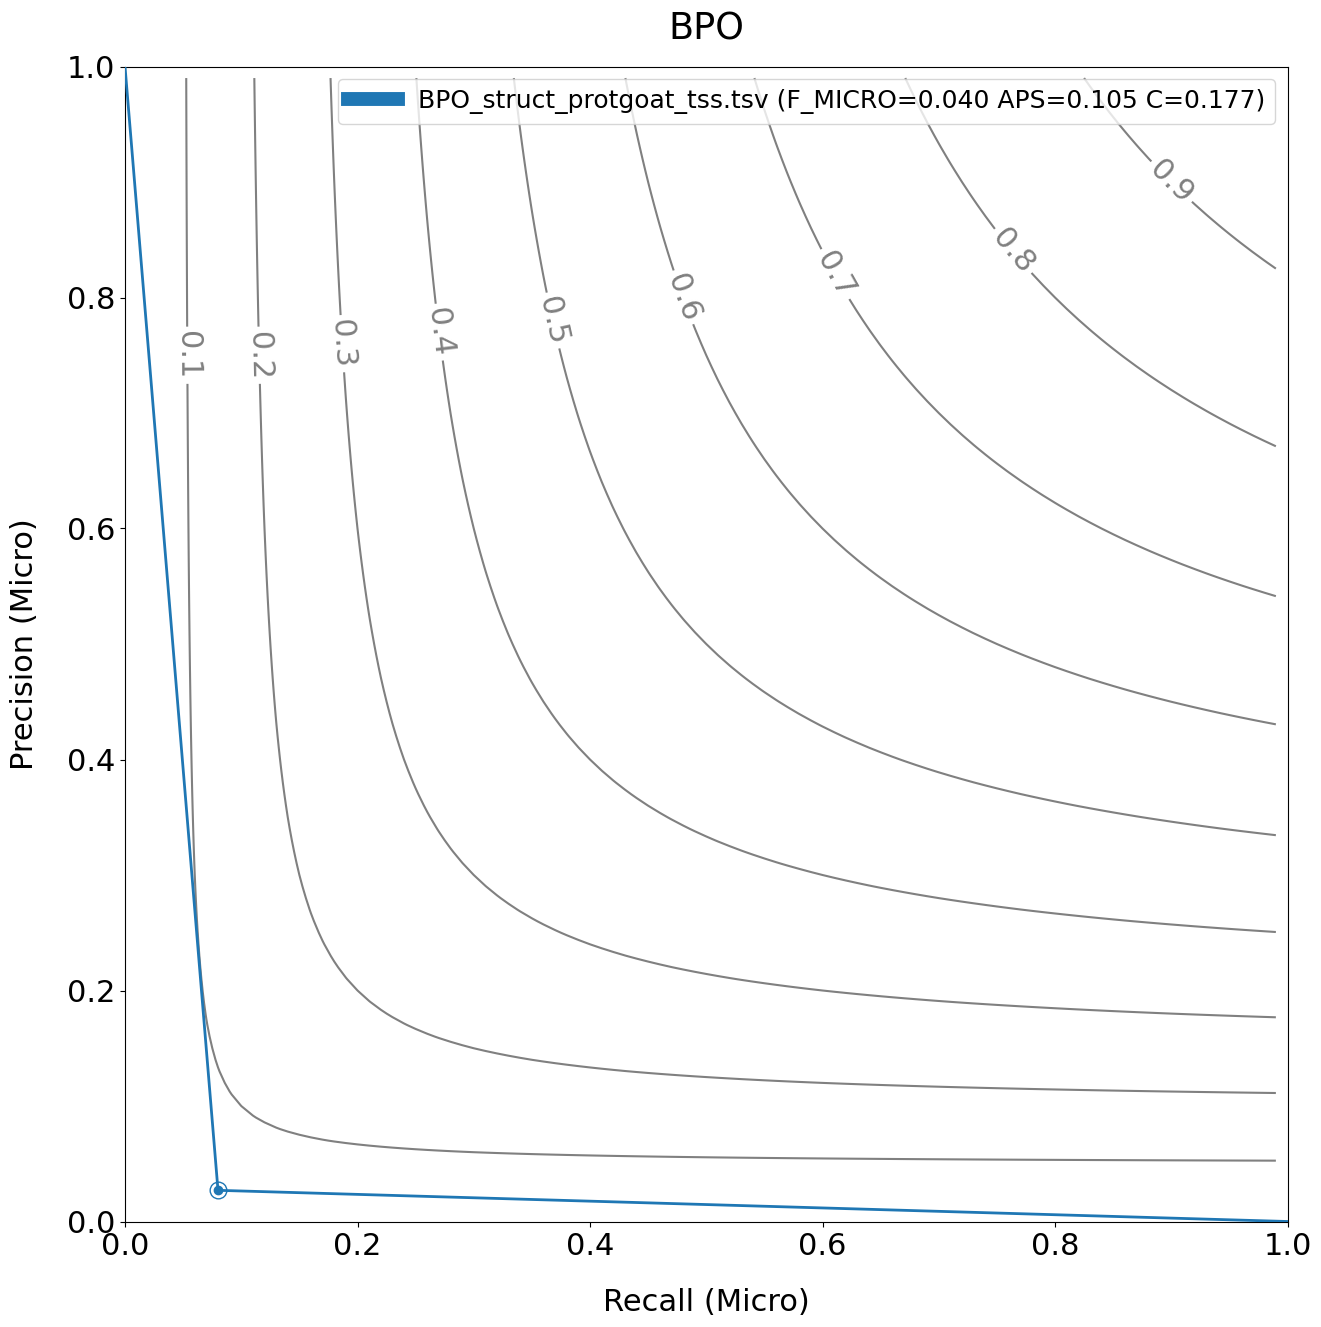

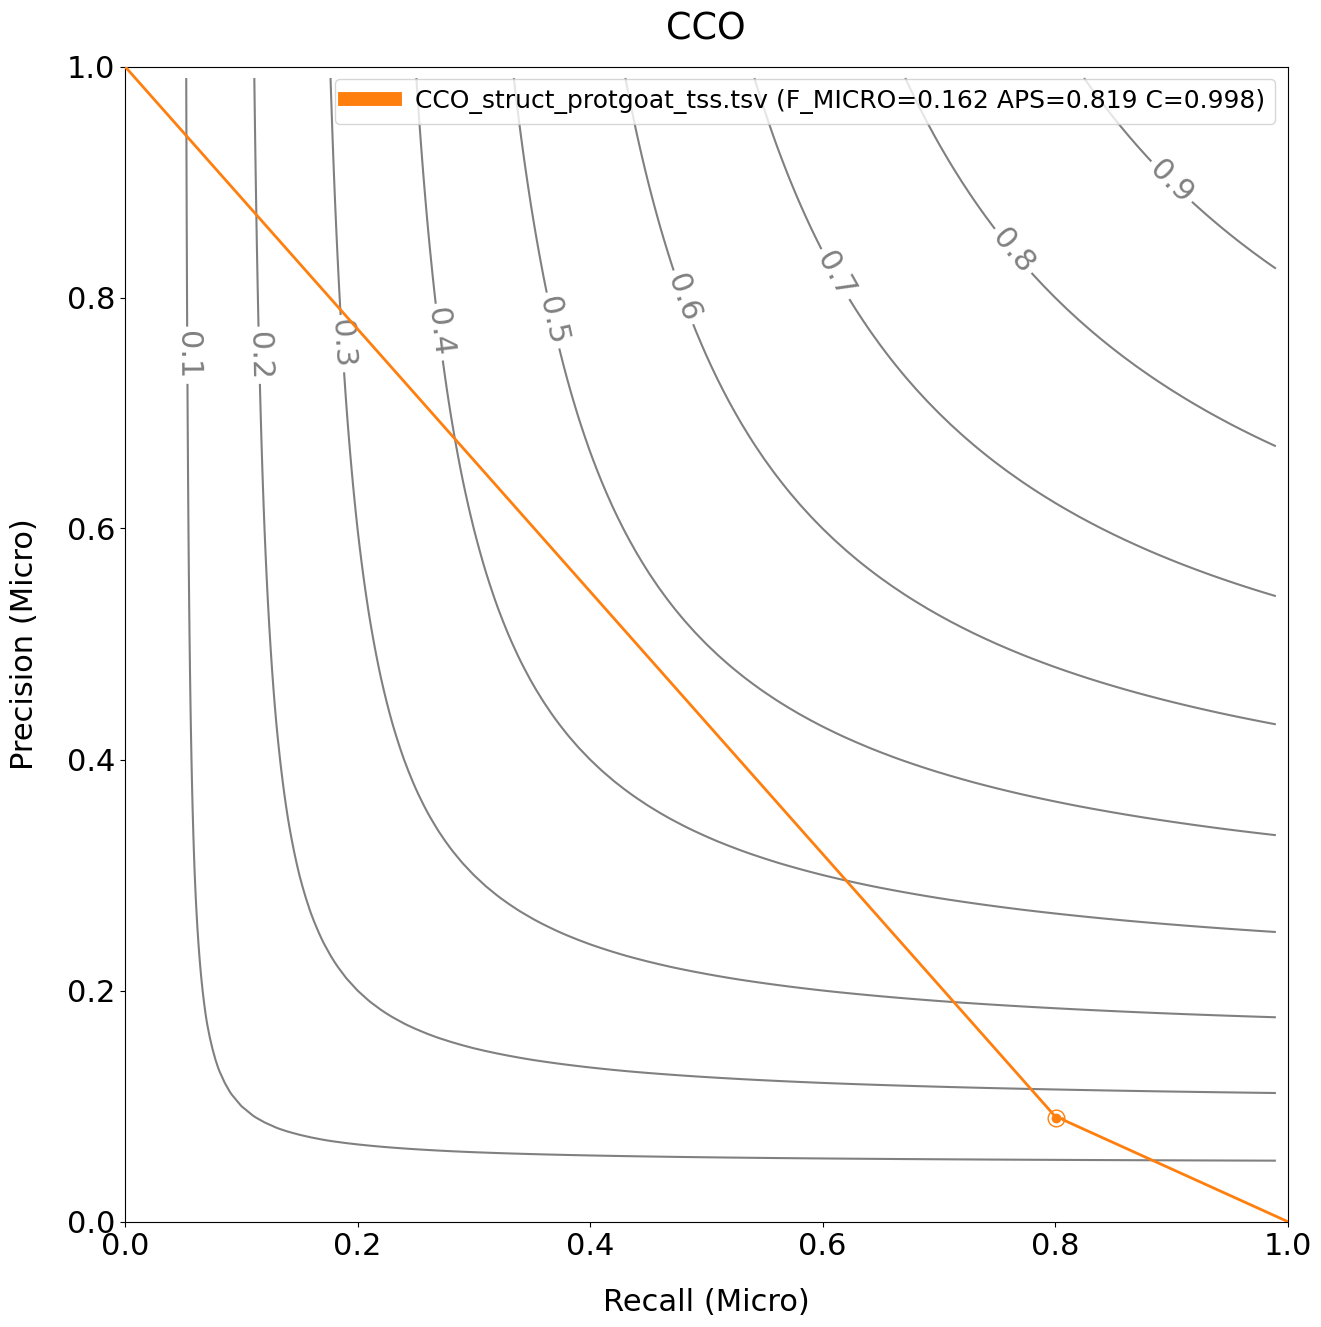

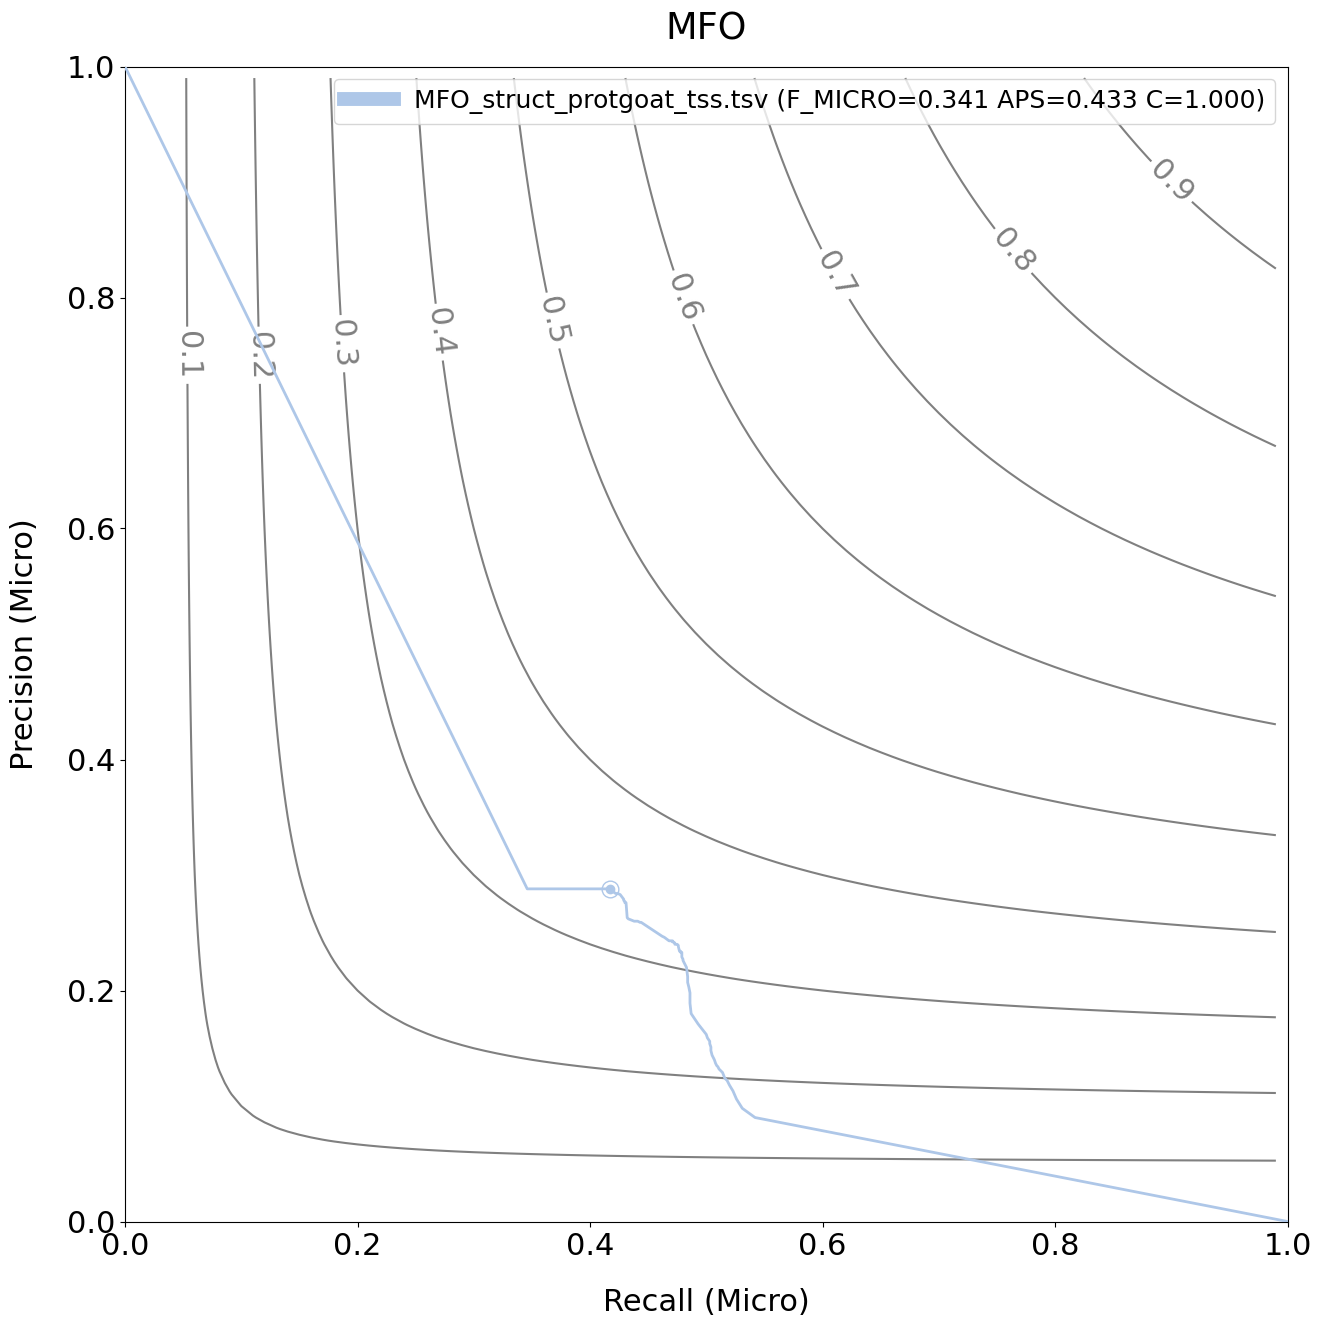

In [72]:
# Generate the figures
plt.rcParams.update({'font.size': 22, 'legend.fontsize': 18})

# F-score contour lines
x = np.arange(0.01, 1, 0.01)
y = np.arange(0.01, 1, 0.01)
X, Y = np.meshgrid(x, y)
Z = 2 * X * Y / (X + Y)

for ns, df_g in df_best.groupby(level='ns'):
    fig, ax = plt.subplots(figsize=(15, 15))

     # Contour lines. At the moment they are provided only for the F-score
    if metric.startswith('f'):
        CS = ax.contour(X, Y, Z, np.arange(0.1, 1.0, 0.1), colors='gray')
        ax.clabel(CS, inline=True) #, fontsize=10)

    # Iterate methods
    for i, (index, row) in enumerate(df_g.sort_values(by=[metric, 'max_cov'], ascending=[False if metric.startswith('f') else True, False]).iterrows()):
        data = df_methods.loc[index[:-1]]

        # Precision-recall or mi-ru curves
        ax.plot(data[cols[0]], data[cols[1]], color=row['colors'], label=row['label'], lw=2, zorder=500-i)

        # F-max or S-min dots
        ax.plot(row[cols[0]], row[cols[1]], color=row['colors'], marker='o', markersize=12, mfc='none', zorder=1000-i)
        ax.plot(row[cols[0]], row[cols[1]], color=row['colors'], marker='o', markersize=6, zorder=1000-i)

    # Set axes limit
    if metric.startswith('f'):
        plt.xlim(0, 1)
        plt.ylim(0, 1)

    # plt.xlim(0, max(1, df_best.loc[:,:,ns,:][cols[0]].max()))
    # plt.ylim(0, max(1, df_best.loc[:,:,ns,:][cols[1]].max()))

    # Set titles
    ax.set_title(ontology_dict.get(ns, ns), pad=20)
    ax.set_xlabel(axis_title_dict[cols[0]], labelpad=20)
    ax.set_ylabel(axis_title_dict[cols[1]], labelpad=20)

    # Legend
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    leg = ax.legend(markerscale=6)
    for legobj in leg.get_lines():
        legobj.set_linewidth(10.0)

    # Save figure on disk
    plt.savefig("{}/fig_{}_{}.png".format(out_folder, metric, ns), bbox_inches='tight', dpi=300, transparent=True)
    # plt.clf()